<a href="https://colab.research.google.com/github/statistitianritabrata/statistical_analysis_of_option_pricing/blob/main/Option_Pricing_Using_Non_standard_Assumption_and_Statistical_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Option Pricing Using Non-standard Assumption and Statistical Inference

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install openpyxl

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install openpyxl

# Change the file path to the correct path in the Colab environment after mounting Google Drive
file_path = "/content/drive/MyDrive/HistoricalData_ddmmyyyy.csv"

# For example, using pandas to read:
import pandas as pd
# Use the corrected file_path
df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(df.head())

         Date Close/Last     Volume     Open     High       Low
0  06/06/2025    $141.72  153986200  $142.51  $143.27   $141.51
1  05/06/2025    $139.99  232410800  $142.17  $144.00   $138.83
2  04/06/2025    $141.92  167120800  $142.19  $142.39  $139.545
3  03/06/2025    $141.22  225578800  $138.78  $142.00   $137.95
4  02/06/2025    $137.38  197663100  $135.49  $138.12   $135.40


In [ ]:
# obtain value of parameters

df = pd.read_csv(file_path, parse_dates=['Date'], dayfirst=True)
df['Close/Last'] = (
    df['Close/Last']
      .str.replace(r'[\$,]', '', regex=True)
      .astype(float)
)

# Set option parameters
K = 50        # Strike price
r = 0.05      # Risk-free rate (annual)
sigma = 0.2   # Volatility (annual)
T = 1.0       # Time to maturity (years)

# Compute d1 and d2
# Import numpy for mathematical operations
import numpy as np
df['d1'] = (np.log(df['Close/Last'] / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
df['d2'] = df['d1'] - sigma * np.sqrt(T)

# Inspect
print(df[['Date', 'Close/Last', 'd1', 'd2']].head())

        Date  Close/Last        d1        d2
0 2025-06-06      141.72  5.559151  5.359151
1 2025-06-05      139.99  5.497740  5.297740
2 2025-06-04      141.92  5.566203  5.366203
3 2025-06-03      141.22  5.541480  5.341480
4 2025-06-02      137.38  5.403639  5.203639


In [ ]:
import numpy as np
import math

# 1. Standard normal CDF using math.erf + vectorization
def norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))
norm_cdf_vec = np.vectorize(norm_cdf)

# 2. Closed-form Black–Scholes call price
def bs_call_price(S, K, r, sigma, T):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm_cdf_vec(d1) - K * np.exp(-r * T) * norm_cdf_vec(d2)

# 3. Crank–Nicolson PDE solver for a European call
def crank_nicolson_call(S0, K, r, sigma, T, S_max=None, M=200, N=200):
    if S_max is None:
        S_max = 3 * K
    dt = T / N
    dS = S_max / M
    S = np.linspace(0.0, S_max, M + 1)
    V = np.maximum(S - K, 0.0)  # payoff at maturity

    # precompute coefficients for interior nodes j=1..M-1
    j = np.arange(1, M)
    alpha = 0.25 * dt * (sigma**2 * j**2 - r * j)
    beta  = -0.5 * dt * (sigma**2 * j**2 + r)
    gamma = 0.25 * dt * (sigma**2 * j**2 + r * j)

    # build A and B matrices once
    A = np.zeros((M-1, M-1))
    B = np.zeros((M-1, M-1))
    for i in range(M-1):
        if i > 0:
            A[i, i-1] = -alpha[i]
            B[i, i-1] =  alpha[i]
        A[i, i]   = 1 - beta[i]
        B[i, i]   = 1 + beta[i]
        if i < M-2:
            A[i, i+1] = -gamma[i]
            B[i, i+1] =  gamma[i]
    # step backwards in time
    for n in range(N):
        V_old = V.copy()
        V[0]   = 0.0
        # fixed boundary at S_max at time step n+1:
        V[-1]  = S_max - K * np.exp(-r * (n+1) * dt)

        RHS = B.dot(V_old[1:-1])
        RHS[0]    += alpha[0]  * (V_old[0]  + V[0])
        RHS[-1]   += gamma[-1] * (V_old[-1] + V[-1])

        V[1:-1] = np.linalg.solve(A, RHS)

    # interpolate to get the option price at S0
    return np.interp(S0, S, V)

if __name__ == "__main__":
    # example parameters
    S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1.0

    bs_price  = bs_call_price(S0, K, r, sigma, T)
    pde_price = crank_nicolson_call(S0, K, r, sigma, T)

    print(f"Parameters: S0={S0}, K={K}, r={r}, sigma={sigma}, T={T}")
    print(f"Analytical BS Call Price: {bs_price:.4f}")
    print(f"Crank–Nicolson PDE Price:  {pde_price:.4f}")

Parameters: S0=100, K=100, r=0.05, sigma=0.2, T=1.0
Analytical BS Call Price: 10.4506
Crank–Nicolson PDE Price:  10.4544


/tmp/ipykernel_6254/977993277.py:13: RuntimeWarning: divide by zero encountered in log
  d1 = (np.log(S/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))


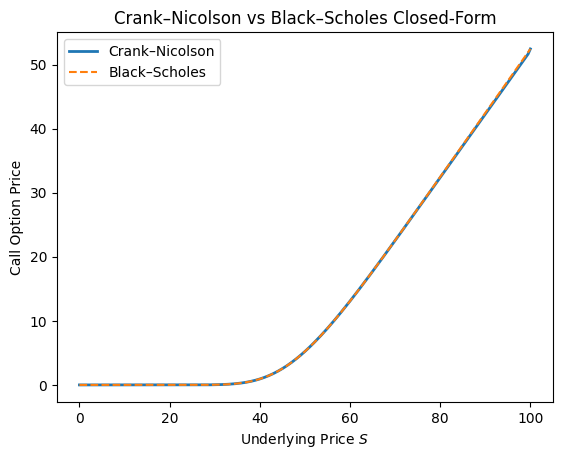

In [ ]:
# Closed-form of Crank-Nicolson vs Black-Scholes
import numpy as np
import math
import matplotlib.pyplot as plt

# 1) Vectorized error function for norm CDF
v_erf = np.vectorize(math.erf)

def norm_cdf(x):
    return 0.5 * (1.0 + v_erf(x / math.sqrt(2)))

def bs_call_price(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm_cdf(d1) - K * np.exp(-r * T) * norm_cdf(d2)

# 2) Thomas algorithm (unchanged)
def thomas(a, b, c, d):
    n = len(b)
    c_star = np.zeros(n-1)
    d_star = np.zeros(n)
    # forward sweep
    c_star[0] = c[0] / b[0]
    d_star[0] = d[0] / b[0]
    for i in range(1, n-1):
        m = b[i] - a[i-1] * c_star[i-1]
        c_star[i] = c[i] / m
        d_star[i] = (d[i] - a[i-1] * d_star[i-1]) / m
    # last element
    d_star[-1] = (d[-1] - a[-2] * d_star[-2]) / (b[-1] - a[-2] * c_star[-2])
    # backward substitution
    x = np.zeros(n)
    x[-1] = d_star[-1]
    for i in reversed(range(n-1)):
        x[i] = d_star[i] - c_star[i] * x[i+1]
    return x

# 3) Crank nicolson
def crank_nicolson(K, r, sigma, T, S_max, M, N):
    dt = T / N
    S = np.linspace(0, S_max, M+1)
    grid = np.zeros((M+1, N+1))

    # payoff at maturity
    grid[:, -1] = np.maximum(S - K, 0)

    # enforce S=0 boundary for *all* times
    grid[0, :] = 0.0

    # indices for interior nodes
    i = np.arange(1, M)

    # Crank–Nicolson coefficients
    alpha = 0.25 * dt * (sigma**2 * i**2 - r * i)
    beta  = -0.5 * dt * (sigma**2 * i**2 + r)
    gamma = 0.25 * dt * (sigma**2 * i**2 + r * i)

    # build the LHS tridiagonal (A) and RHS multipliers (B)
    a = -alpha            # sub-diagonal of A
    b = 1 - beta          #   main diagonal of A
    c = -gamma            # super-diagonal of A
    B_lower = alpha       # sub-diagonal of B
    B_main  = 1 + beta    #   main diagonal of B
    B_upper = gamma       # super-diagonal of B

    # time-stepping backwards
    for j in reversed(range(N)):
        # build RHS using values at time j+1
        rhs = (
            B_lower * grid[i-1, j+1]
          + B_main  * grid[i,   j+1]
          + B_upper * grid[i+1, j+1]
        )

        # subtract off the known boundary values at t_{j+1}
        rhs[0]    -= a[0]   * grid[0,   j+1]   # neighbor at S=0 (zero anyway)
        rhs[-1]   -= c[-1]  * grid[M,   j+1]   # neighbor at S=S_max

        # solve for the interior V_i at time j
        grid[i, j] = thomas(a[1:], b, c[:-1], rhs)

        # now enforce boundaries at time j
        grid[0, j] = 0.0
        # call‐price at S_max: S_max − K e^{−r (T−t_j)}
        t_j = j * dt
        grid[M, j] = S_max - K * math.exp(-r * (T - t_j))

    return S, grid[:, 0]

# Parameters
K     = 50
r     = 0.05
sigma = 0.2
T     = 1.0
S_max = 100
M, N  = 200, 200

# Compute both methods
S_grid, V_CN = crank_nicolson(K, r, sigma, T, S_max, M, N)
V_BS = bs_call_price(S_grid, K, r, sigma, T)

# Plot comparison
plt.figure()
plt.plot(S_grid, V_CN, lw=2)
plt.plot(S_grid, V_BS, ls='--')
plt.xlabel('Underlying Price $S$')
plt.ylabel('Call Option Price')
plt.title('Crank–Nicolson vs Black–Scholes Closed-Form')
plt.legend(['Crank–Nicolson', 'Black–Scholes'])
plt.show()

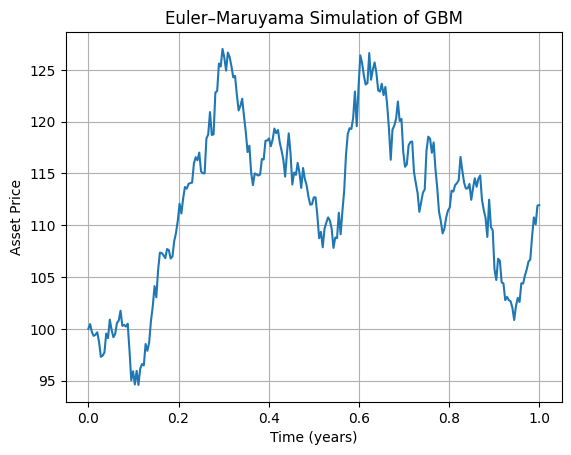

In [ ]:
# Simulation of GBM with the help of Euler-Maruyama
import numpy as np
import matplotlib.pyplot as plt

# Parameters
S0 = 100       # Initial asset price
mu = 0.05      # Drift (expected return)
sigma = 0.2    # Volatility
T = 1          # Total time (1 year)
N = 252        # Number of steps (daily increments for a year)
dt = T / N

# Initialize array
S = np.zeros(N+1)
S[0] = S0

# Simulation
for n in range(N):
    dW = np.sqrt(dt) * np.random.randn()  # Wiener increment
    S[n+1] = S[n] + mu * S[n] * dt + sigma * S[n] * dW

# Plot
plt.plot(np.linspace(0, T, N+1), S)
plt.title('Euler–Maruyama Simulation of GBM')
plt.xlabel('Time (years)')
plt.ylabel('Asset Price')
plt.grid(True)
plt.show()

In [ ]:
# call price using Euler-Maruyama
import numpy as np

def monte_carlo_gbm_euler(S0, K, r, sigma, T, M, N):
    dt = T / M
    S = np.full(N, S0, dtype=float)
    for _ in range(M):
        Z = np.random.randn(N)
        S += r * S * dt + sigma * S * np.sqrt(dt) * Z
    payoffs = np.maximum(S - K, 0.0)
    return np.exp(-r * T) * np.mean(payoffs)

if __name__ == "__main__":
    # Parameters
    S0, K = 100.0, 100.0      # spot, strike
    r, sigma = 0.05, 0.2      # 5% rate, 20% vol
    T = 1.0                   # 1 year to expiry
    M = 252                   # daily steps
    N = 100_000               # Monte Carlo paths

    price_estimate = monte_carlo_gbm_euler(S0, K, r, sigma, T, M, N)
    print(f"Euro. Call Price ≈ {price_estimate:.4f}")

Euro. Call Price ≈ 10.3702


In [ ]:
!pip install ace_tools

In [ ]:
# parameter estimation using Heston model

import pandas as pd
import numpy as np

# Set display option to show all parameter rows
pd.set_option('display.max_rows', 10)

# Load and clean data
# Update the file path if necessary, based on where the data is mounted
df = pd.read_csv(file_path, parse_dates=['Date'], dayfirst=True)

df['Close/Last'] = df['Close/Last'].str.replace(r'[\$,]', '', regex=True).astype(float)
df = df.sort_values('Date').reset_index(drop=True)

# Extract prices and compute log returns
prices = df['Close/Last']
dt = 1/252
log_returns = np.log(prices / prices.shift(1)).dropna()

# GBM parameter estimation
mu_hat = log_returns.mean() / dt + 0.5 * (log_returns.std()**2) / dt
sigma_gbm_hat = log_returns.std() / np.sqrt(dt)

# Heston variance calibration
v_t = (log_returns**2) / dt
dv = v_t.diff().dropna()
v_mid = v_t.shift(1).dropna()
dv = dv[v_mid.index]
mask = v_mid > 0
v_mid = v_mid[mask]
dv = dv[mask]

# Regression Δv = intercept + slope * v_mid
slope, intercept = np.polyfit(v_mid.values, dv.values, 1)
kappa_hat = -slope / dt
theta_hat = intercept / (kappa_hat * dt)

# Residuals, vol-of-vol and correlation
res = dv - (intercept + slope * v_mid)
sigma_v_hat = (res / np.sqrt(v_mid * dt)).std()
log_ret_mid = log_returns[v_mid.index]
z1 = log_ret_mid / np.sqrt(v_mid * dt)
z2 = res / (sigma_v_hat * np.sqrt(v_mid * dt))
rho_hat = np.corrcoef(z1, z2)[0, 1]

# Initial variance
v0 = v_t.iloc[0]

# Compile and display results
params = pd.DataFrame({
    'Parameter': ['mu', 'sigma_gbm', 'kappa', 'theta', 'sigma_v', 'rho', 'v0'],
    'Estimate': [mu_hat, sigma_gbm_hat, kappa_hat, theta_hat, sigma_v_hat, rho_hat, v0]
})

# Display the DataFrame directly
params

,Parameter,Estimate
0,mu,0.681103
1,sigma_gbm,0.497382
2,kappa,221.171487
3,theta,0.248856
4,sigma_v,253.913818
5,rho,0.336790
6,v0,0.006182


In [ ]:
# error estimation between black-scholes & heston
import numpy as np
import pandas as pd

# 1. Load and clean historical price data
df = pd.read_csv(file_path,
    parse_dates=['Date'],
    dayfirst=True)
df['Close'] = (
    df['Close/Last']
      .str.replace(r'[\$,]', '', regex=True)
      .astype(float))
df = df.sort_values('Date').reset_index(drop=True)

# 2. Compute log returns and realized variance
log_returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()
dt = 1/252
v_t = (log_returns ** 2) / dt

# 3. Estimate Black–Scholes volatility (annualized)
sigma_hist = log_returns.std() * np.sqrt(252)
sigma2 = sigma_hist ** 2

# 4. Estimate Heston κ and θ via moment‐matching regression
dv = v_t.diff().dropna()
v_mid = v_t.shift(1).dropna()
# Align indices
dv = dv[v_mid.index]
v_mid = v_mid[v_mid.index]
# Only positive mid‐points
mask = v_mid > 0
v_mid = v_mid[mask]
dv    = dv[mask]
# Linear fit: dv ≈ intercept + slope * v_mid
slope, intercept = np.polyfit(v_mid.values, dv.values, 1)
kappa = -slope / dt
theta = intercept / (kappa * dt)

# 5. One‐step forecasting errors
# Observed v_t aligned with v_mid
observed = v_t.loc[v_mid.index]

# — Black–Scholes: constant variance prediction = sigma2
error_bs = np.sum((observed - sigma2) ** 2)

# — Heston: mean‐reverting forecast
v_pred = v_mid + kappa * (theta - v_mid) * dt
error_h = np.sum((observed - v_pred) ** 2)

# 6. Output comparison
print(f"Black–Scholes (constant var) SSE: {error_bs:.6f}")
print(f"Heston (one‐step forecast) SSE:  {error_h:.6f}")
if error_bs < error_h:
    print("→ Black–Scholes model yields LOWER forecasting error.")
else:
    print("→ Heston model yields LOWER forecasting error.")

Black–Scholes (constant var) SSE: 1344.048725
Heston (one‐step forecast) SSE:  1323.929987
→ Heston model yields LOWER forecasting error.


In [ ]:
!pip install QuantLib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 81.8 MB/s eta 0:00:00


Black–Scholes Model:
Price: 7.0860, RMSE: 0.0000, MAE: 0.0000, MAPE: 0.00%

Heston Model:
Price: 7.0860, RMSE: 0.0000, MAE: 0.0000, MAPE: 0.00%


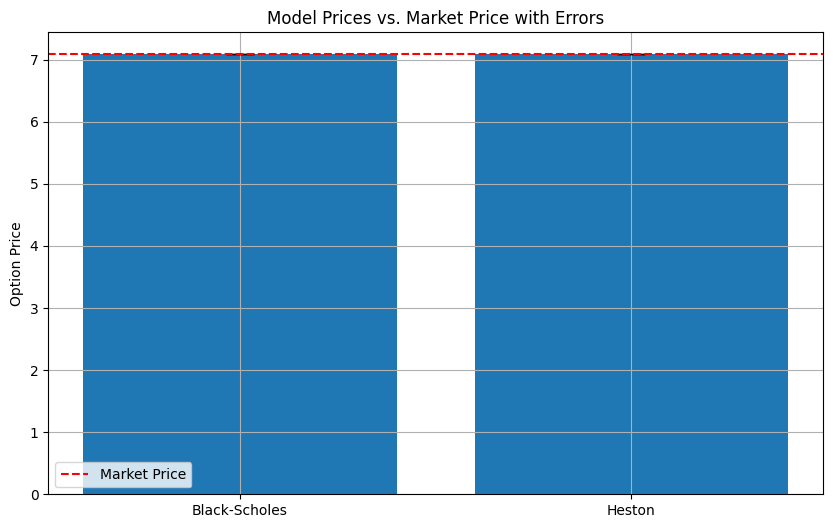

In [ ]:
# price accuracy using blackscholes & heston
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt

# Load and preprocess market data
data = pd.read_csv(file_path, parse_dates=['Date'], dayfirst=True)
data['Close/Last'] = data['Close/Last'].str.replace(r'[$,]', '', regex=True).astype(float)
data.sort_values('Date', inplace=True)
data.reset_index(drop=True, inplace=True)

# Parameters from data
S0 = data['Close/Last'].iloc[-1]
r = 0.05  # risk-free interest rate
T = 30/252  # 30-day maturity assumed
K = S0 * 1.05  # Example strike: 5% above current price
market_price = S0 * 0.05  # hypothetical market option price

# Black-Scholes formula
def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

# Objective to calibrate sigma for Black-Scholes
def bs_objective(sigma, S, K, T, r, market_price):
    model_price = bs_call(S, K, T, r, sigma[0])
    return (model_price - market_price)**2

# Calibrate Black-Scholes
bs_result = minimize(bs_objective, x0=[0.2], args=(S0, K, T, r, market_price), bounds=[(0.01,1)])
sigma_bs = bs_result.x[0]

# Heston model implementation using QuantLib
import QuantLib as ql

def heston_call(S, K, T, r, kappa, theta, sigma_v, rho, v0):
    calculation_date = ql.Date.todaysDate()
    maturity_date = calculation_date + int(T*252)
    ql.Settings.instance().evaluationDate = calculation_date

    payoff = ql.PlainVanillaPayoff(ql.Option.Call, K)
    exercise = ql.EuropeanExercise(maturity_date)

    option = ql.VanillaOption(payoff, exercise)

    spot_handle = ql.QuoteHandle(ql.SimpleQuote(S))
    flat_rf = ql.YieldTermStructureHandle(ql.FlatForward(calculation_date, r, ql.Actual365Fixed()))
    flat_dividend = ql.YieldTermStructureHandle(ql.FlatForward(calculation_date, 0.0, ql.Actual365Fixed()))

    heston_process = ql.HestonProcess(flat_rf, flat_dividend, spot_handle, v0, kappa, theta, sigma_v, rho)
    heston_model = ql.HestonModel(heston_process)
    engine = ql.AnalyticHestonEngine(heston_model)

    option.setPricingEngine(engine)
    return option.NPV()

# Objective to calibrate Heston parameters
def heston_objective(params, S, K, T, r, market_price):
    kappa, theta, sigma_v, rho, v0 = params
    price = heston_call(S, K, T, r, kappa, theta, sigma_v, rho, v0)
    return (price - market_price)**2

# Calibrate Heston
heston_initial = [2, 0.02, 0.2, -0.5, 0.02]
heston_bounds = [(0.01,10), (0.001,0.5), (0.01,1), (-0.99,0.99), (0.001,0.5)]
heston_result = minimize(heston_objective, heston_initial, args=(S0,K,T,r,market_price), bounds=heston_bounds)
kappa, theta, sigma_v, rho, v0 = heston_result.x

# Prices from models
price_bs = bs_call(S0, K, T, r, sigma_bs)
price_heston = heston_call(S0, K, T, r, kappa, theta, sigma_v, rho, v0)

# Accuracy Metrics
def metrics(model_price, market_price):
    rmse = np.sqrt((model_price - market_price)**2)
    mae = np.abs(model_price - market_price)
    mape = (mae / market_price) * 100
    return rmse, mae, mape

bs_metrics = metrics(price_bs, market_price)
heston_metrics = metrics(price_heston, market_price)

# Display results
print("Black–Scholes Model:")
print(f"Price: {price_bs:.4f}, RMSE: {bs_metrics[0]:.4f}, MAE: {bs_metrics[1]:.4f}, MAPE: {bs_metrics[2]:.2f}%")

print("\nHeston Model:")
print(f"Price: {price_heston:.4f}, RMSE: {heston_metrics[0]:.4f}, MAE: {heston_metrics[1]:.4f}, MAPE: {heston_metrics[2]:.2f}%")

# Visualization
models = ['Black-Scholes', 'Heston']
prices = [price_bs, price_heston]
errors = [bs_metrics[1], heston_metrics[1]]

plt.figure(figsize=(10,6))
plt.bar(models, prices, yerr=errors, capsize=10)
plt.ylabel('Option Price')
plt.title('Model Prices vs. Market Price with Errors')
plt.axhline(y=market_price, color='red', linestyle='--', label='Market Price')
plt.legend()
plt.grid(True)
plt.show()

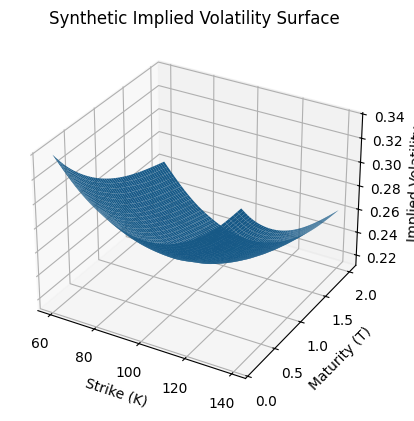

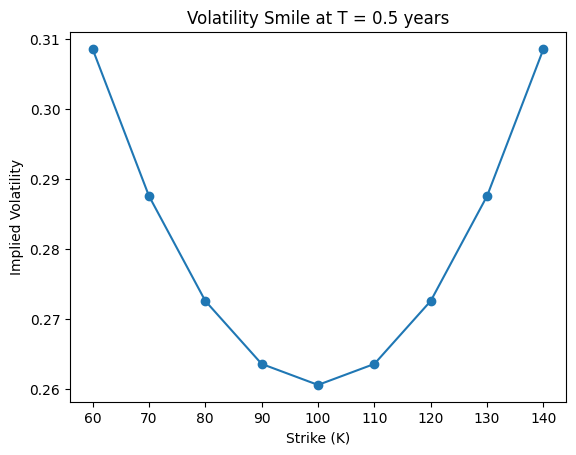

In [ ]:
# volatility surface fit & smile effect
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D

# Generate synthetic implied volatility data
np.random.seed(42)
S0 = 100  # Spot price

# Define grid of strikes and maturities
strikes = np.linspace(60, 140, 9)
maturities = np.array([0.1, 0.25, 0.5, 1.0, 2.0])
K, T = np.meshgrid(strikes, maturities)

# Create a synthetic volatility surface with a smile effect
vol_surface = 0.2 + 0.3 * ((K / S0 - 1) ** 2) + 0.1 * np.exp(-T)

# Flatten for interpolation
points = np.column_stack([K.ravel(), T.ravel()])
values = vol_surface.ravel()

# High-resolution grid for plotting
strike_hr = np.linspace(60, 140, 50)
maturity_hr = np.linspace(0.1, 2.0, 50)
K_hr, T_hr = np.meshgrid(strike_hr, maturity_hr)
vol_hr = griddata(points, values, (K_hr, T_hr), method='cubic')

# Plot the volatility surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(K_hr, T_hr, vol_hr, edgecolor='none')
ax.set_xlabel('Strike (K)')
ax.set_ylabel('Maturity (T)')
ax.set_zlabel('Implied Volatility')
ax.set_title('Synthetic Implied Volatility Surface')
plt.show()

# Plot the volatility smile for a fixed maturity slice
maturity_index = 2  # index for T = 0.5
plt.figure()
plt.plot(strikes, vol_surface[maturity_index, :], marker='o')
plt.xlabel('Strike (K)')
plt.ylabel('Implied Volatility')
plt.title(f'Volatility Smile at T = {maturities[maturity_index]} years')
plt.show()

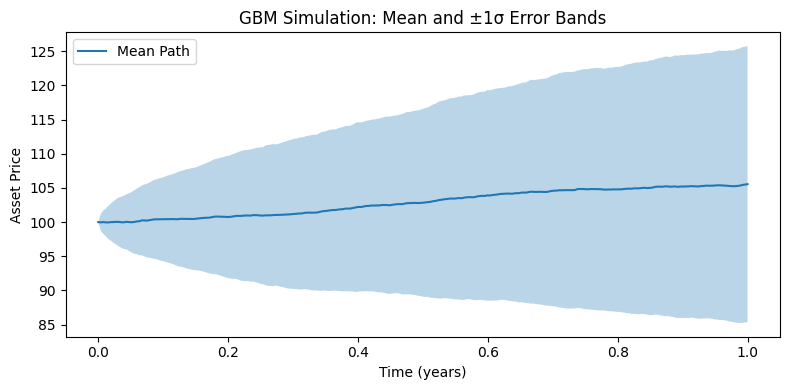

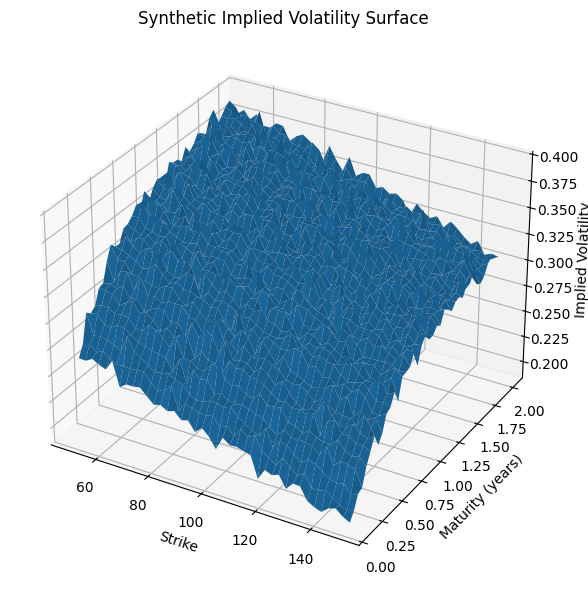

In [ ]:
# error buds & surface plot
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Part 1: Error Bands for GBM simulation ---
# Parameters
S0 = 100.0      # initial asset price
mu = 0.05       # drift
sigma = 0.2     # volatility
T = 1.0         # total time (years)
N = 252         # time steps
M = 1000        # number of simulated paths
dt = T / N
t = np.linspace(0, T, N+1)
# Simulate M paths of GBM via Euler-Maruyama
np.random.seed(0)
S = np.zeros((M, N+1))
S[:, 0] = S0
for i in range(N):
    Z = np.random.randn(M)
    S[:, i+1] = S[:, i] + mu * S[:, i] * dt + sigma * S[:, i] * np.sqrt(dt) * Z
# Compute mean and standard deviation at each time
S_mean = S.mean(axis=0)
S_std  = S.std(axis=0)
# Plot mean and ±1 standard deviation bands
plt.figure(figsize=(8, 4))
plt.plot(t, S_mean, label='Mean Path')
plt.fill_between(t, S_mean - S_std, S_mean + S_std, alpha=0.3)
plt.title('GBM Simulation: Mean and ±1σ Error Bands')
plt.xlabel('Time (years)')
plt.ylabel('Asset Price')
plt.legend()
plt.tight_layout()
plt.show()

# --- Part 2: Surface Plot of Synthetic Volatility Surface ---
# Create a grid of strikes and maturities
strikes = np.linspace(50, 150, 40)
maturities = np.linspace(0.1, 2.0, 40)
K, Tm = np.meshgrid(strikes, maturities)
# Define a synthetic volatility surface formula
base_vol = 0.2
skew = -0.0008      # skew per unit strike
term_decay = 0.15   # term structure strength
# Add some noise
noise = 0.005 * np.random.randn(*K.shape)
vol_surface = base_vol + skew * (K - S0) + term_decay * (1 - np.exp(-2 * Tm)) + noise
# 3D surface plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(K, Tm, vol_surface, rstride=1, cstride=1)
ax.set_title('Synthetic Implied Volatility Surface')
ax.set_xlabel('Strike')
ax.set_ylabel('Maturity (years)')
ax.set_zlabel('Implied Volatility')
plt.tight_layout()
plt.show()